In [19]:
import os
import random
import csv
import cv2
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna as op
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix, ConfusionMatrixDisplay

In [21]:
features=[]
class_label=[]
c=0
for folder in os.listdir(r"C:\Users\HP\Documents\datascience projects\facial attendance system\image"):
    for images in random.sample(os.listdir(r"C:\Users\HP\Documents\datascience projects\facial attendance system\image\{}".format(folder)), min(100, len(os.listdir(r"C:\Users\HP\Documents\datascience projects\facial attendance system\images\{}".format(folder))))):
        image=cv2.imread(r"C:\Users\HP\Documents\datascience projects\facial attendance system\image\{}\{}".format(folder,images))
        features.append(cv2.resize(image,(100,100)).flatten())
        class_label.append(c)
    c+=1

In [22]:
data = pd.DataFrame(features)
data = data.astype(np.uint8)

In [23]:
data.info()

In [24]:
data.head(3)

In [25]:
len(X_train)

320

In [9]:
degree_cache = {}

In [10]:
def objective(trial):
    model_name = trial.suggest_categorical("Algorithm", ['SVC', 'Logistic Regression','Decision Tree'])

    if model_namez == 'Logistic Regression':
        poly_degree = trial.suggest_int("poly_degree", 1,1)
        if poly_degree not in degree_cache:
            pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=poly_degree)),
                ('scaler', StandardScaler())
            ])
            x_train_poly = pipeline.fit_transform(X_train)
            degree_cache[poly_degree] = x_train_poly
        else:
            x_train_poly = degree_cache[poly_degree]

        solver_penalty_combinations = [
            ("lbfgs", "l2"),
            ("newton-cg", "l2"),
            ("sag", "l2"),
            ("saga", "l1"),
            ("saga", "l2"),
            ("saga", "elasticnet")
        ]
        solv, penalty = trial.suggest_categorical("solver_penalty", solver_penalty_combinations)
        c = trial.suggest_float("C", 1e-4, 1e3, log=True)

        if penalty == "elasticnet":
            l1_rto = trial.suggest_float("l1_ratio", 0.1, 0.9, step=0.1)
            model = LogisticRegression(
                C=c, 
                solver=solv, 
                penalty=penalty, 
                l1_ratio=l1_rto, 
                n_jobs=-1, 
                max_iter=1000,
                random_state=42
            )
        else:
            model = LogisticRegression(
                C=c, 
                solver=solv, 
                penalty=penalty, 
                n_jobs=-1, 
                max_iter=1000,
                random_state=42
            )

    elif model_name == 'SVC':
        c = trial.suggest_float("C", 1e-4, 1e3, log=True)
        ker_nel = trial.suggest_categorical("Kernel", ['linear', 'poly', 'rbf', 'sigmoid'])

        if ker_nel == 'poly':
            deg_ree = trial.suggest_int("Degree", 1, 3)
            model = SVC(
                C=c, 
                kernel=ker_nel, 
                degree=deg_ree,
                random_state=42
            )
        elif ker_nel in ['rbf', 'sigmoid']:
            gamma = trial.suggest_categorical("Gamma", ['scale', 'auto'])
            model = SVC(
                C=c, 
                kernel=ker_nel, 
                gamma=gamma,
                random_state=42
            )
        else:
            model = SVC(
                C=c,
                kernel=ker_nel,
                random_state=42
            )
    else:
        max_depth = trial.suggest_int("max_depth", 3, 20)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
        criterion = trial.suggest_categorical("criterion", ['gini', 'entropy', 'log_loss'])

        model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            criterion=criterion,
            random_state=42
        )

    # Use transformed data for Logistic Regression, original data for others
    X_train_transformed = x_train_poly if model_name == 'Logistic Regression' else X_train

    try:
        cv_results = cross_validate(
            estimator=model,
            X=X_train_transformed,
            y=y_train,
            cv=3,
            scoring="accuracy",
            return_train_score=True,
            n_jobs=-1,
        )
        train_score = np.mean(cv_results['train_score'])
        test_score = np.mean(cv_results['test_score'])
    except ValueError as e:
        print(f"Error during cross-validation for model {model_name} with params {trial.params}: {e}")
        train_score = float("nan")
        test_score = float("nan")

    trial.set_user_attr("train_score", train_score)
    trial.set_user_attr("test_score", test_score)

    return test_score

In [11]:
study1 = op.create_study(direction="maximize", sampler=op.samplers.TPESampler())

[I 2025-01-31 09:41:09,786] A new study created in memory with name: no-name-e16bfe27-7a5f-4066-805c-b74bff065a2b


In [12]:
study1.optimize(objective, n_jobs=-1, n_trials=50, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('lbfgs', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('newton-cg', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('sag', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distribut

[I 2025-01-31 09:41:23,398] Trial 5 finished with value: 1.0 and parameters: {'Algorithm': 'SVC', 'C': 378.75007606243827, 'Kernel': 'poly', 'Degree': 1}. Best is trial 5 with value: 1.0.
[I 2025-01-31 09:41:39,555] Trial 3 finished with value: 0.24375477575971316 and parameters: {'Algorithm': 'SVC', 'C': 2.9772119403433437, 'Kernel': 'sigmoid', 'Gamma': 'auto'}. Best is trial 5 with value: 1.0.
[I 2025-01-31 09:41:42,932] Trial 7 finished with value: 1.0 and parameters: {'Algorithm': 'SVC', 'C': 31.774808215299842, 'Kernel': 'rbf', 'Gamma': 'scale'}. Best is trial 5 with value: 1.0.
[I 2025-01-31 09:41:46,919] Trial 4 finished with value: 1.0 and parameters: {'Algorithm': 'Decision Tree', 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 5 with value: 1.0.
[I 2025-01-31 09:41:47,532] Trial 0 finished with value: 1.0 and parameters: {'Algorithm': 'SVC', 'C': 0.14031678038243592, 'Kernel': 'rbf', 'Gamma': 'scale'}. Best is trial 5 with va

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('lbfgs', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('newton-cg', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('sag', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distribut

[I 2025-01-31 09:42:01,939] Trial 8 finished with value: 1.0 and parameters: {'Algorithm': 'SVC', 'C': 0.0005096328076488854, 'Kernel': 'linear'}. Best is trial 5 with value: 1.0.
[I 2025-01-31 09:42:02,606] Trial 1 finished with value: 0.24375477575971316 and parameters: {'Algorithm': 'SVC', 'C': 27.730250178765477, 'Kernel': 'sigmoid', 'Gamma': 'auto'}. Best is trial 5 with value: 1.0.
[I 2025-01-31 09:42:07,951] Trial 9 finished with value: 0.9843942867219185 and parameters: {'Algorithm': 'Decision Tree', 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 5 with value: 1.0.


...

[I 2025-01-31 09:42:51,147] Trial 15 finished with value: 0.25947804619996473 and parameters: {'Algorithm': 'SVC', 'C': 0.05767770223212026, 'Kernel': 'rbf', 'Gamma': 'auto'}. Best is trial 5 with value: 1.0.


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('lbfgs', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('newton-cg', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('sag', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distribut

[I 2025-01-31 10:01:06,117] Trial 2 finished with value: 0.9968847352024922 and parameters: {'Algorithm': 'Logistic Regression', 'poly_degree': 1, 'solver_penalty': ('sag', 'l2'), 'C': 189.39278561351676}. Best is trial 5 with value: 1.0.
[I 2025-01-31 10:05:34,913] Trial 19 finished with value: 1.0 and parameters: {'Algorithm': 'Decision Tree', 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 5 with value: 1.0.


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('lbfgs', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('newton-cg', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('sag', 'l2') which is of type tuple.
  warnings.warn(message)
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\distribut

[I 2025-01-31 10:11:53,848] Trial 16 finished with value: 1.0 and parameters: {'Algorithm': 'Logistic Regression', 'poly_degree': 1, 'solver_penalty': ('saga', 'elasticnet'), 'C': 0.14840679356817868, 'l1_ratio': 0.9}. Best is trial 5 with value: 1.0.
[I 2025-01-31 10:15:08,674] Trial 17 finished with value: 1.0 and parameters: {'Algorithm': 'Logistic Regression', 'poly_degree': 1, 'solver_penalty': ('sag', 'l2'), 'C': 0.02901866989879618}. Best is trial 5 with value: 1.0.
[I 2025-01-31 10:28:04,033] Trial 18 finished with value: 1.0 and parameters: {'Algorithm': 'Logistic Regression', 'poly_degree': 1, 'solver_penalty': ('saga', 'l2'), 'C': 0.03147164341090976}. Best is trial 5 with value: 1.0.
[I 2025-01-31 10:32:01,050] Trial 20 finished with value: 1.0 and parameters: {'Algorithm': 'Logistic Regression', 'poly_degree': 1, 'solver_penalty': ('sag', 'l2'), 'C': 0.0538230720857582}. Best is trial 5 with value: 1.0.
[I 2025-01-31 10:32:08,124] Trial 23 finished with value: 1.0 and para

In [13]:
study1.best_params

{'Algorithm': 'SVC', 'C': 378.75007606243827, 'Kernel': 'poly', 'Degree': 1}

In [26]:
poly = PolynomialFeatures(degree=1)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [12]:
svc_model = SVC(C=1.0, kernel='linear', random_state=42)


In [13]:
svc_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [14]:
svc_model = model.fit(X_train_poly,y_train)

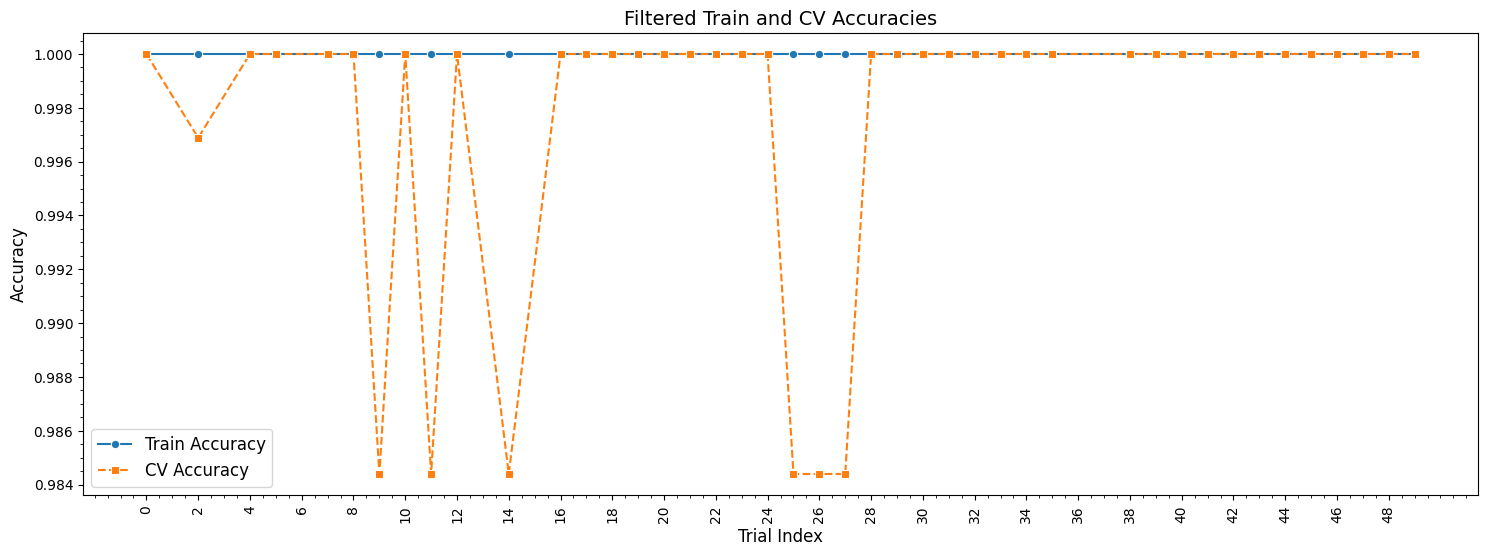

In [16]:
threshold_train_min = 0.0
threshold_train_max = 1.0
threshold_cv = 0.95

filtered_train_accuracies = []z
filtered_cv_accuracies = []
filtered_trial_numbers = []

for trial in study1.trials:
    if trial.state == op.trial.TrialState.COMPLETE:
        train_acc = trial.user_attrs.get("train_score", 0)
        cv_acc = trial.user_attrs.get("test_score", 0)
        if threshold_train_min <= train_acc <= threshold_train_max and cv_acc >= threshold_cv:
            filtered_train_accuracies.append(train_acc)
            filtered_cv_accuracies.append(cv_acc)
            filtered_trial_numbers.append(trial.number)

data = pd.DataFrame({
    'Trial Index': filtered_trial_numbers,
    'Train Accuracy': filtered_train_accuracies,
    'CV Accuracy': filtered_cv_accuracies
})

plt.figure(figsize=(18, 6))
sns.lineplot(x="Trial Index", y="Train Accuracy", data=data, label="Train Accuracy", marker='o', linestyle='-')
sns.lineplot(x="Trial Index", y="CV Accuracy", data=data, label="CV Accuracy", marker='s', linestyle='--')

plt.xlabel("Trial Index", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Filtered Train and CV Accuracies", fontsize=14)
plt.legend(fontsize=12)

plt.minorticks_on()
plt.xticks(ticks=range(min(filtered_trial_numbers), max(filtered_trial_numbers)+1, 2), rotation = 90)

plt.show()

In [15]:
study1.trials_dataframe().iloc[[5]]

,number,value,datetime_start,datetime_complete,duration,params_Algorithm,params_C,params_Degree,params_Gamma,params_Kernel,params_criterion,params_l1_ratio,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_poly_degree,params_solver_penalty,user_attrs_test_score,user_attrs_train_score,state
5,5,1.0,2025-01-31 09:41:09.866248,2025-01-31 09:41:23.394811,0 days 00:00:13.528563,SVC,378.750076,1.0,NaN,poly,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,COMPLETE


In [46]:
vid = cv2.VideoCapture(0) 
while True:
    suc, img = vid.read()
    if not suc or img is None: 
        print("Failed to capture frame. Check camera connection.")
        break

    now = datetime.now()

    cv2.rectangle(img, (240, 100), (480, 450), (1, 1, 1), 1)

    crop_img = img[100:450, 240:480]

    xq = cv2.resize(crop_img, (100, 100)).flatten()
    xq = xq.reshape((1, 30000))

    y_i = svc_model.predict(xq)  
    cv2.putText(img, now.strftime("%H:%M:%S"), (10, 20), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 1)
    cv2.putText(img, "Face Attendance System", (10, 60), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 255, 255), 1)
    cv2.putText(img, "Press Y to Mark Your Attendance", (10, 90), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 255, 255), 1)

    if y_i[0] == 0:
        cv2.putText(img, "Aamer", (100, 150), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 1)
        person_name = "Aamer"
    elif y_i[0] == 1:
        cv2.putText(img, "KVS", (100, 150), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 1)
        person_name = "KVS"
    elif y_i[0] == 2:
        cv2.putText(img, "Rohith", (100, 150), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 1)
        person_name = "Rohith"
    elif y_i[0] == 3:
        cv2.putText(img, "Wazid", (100, 150), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 1)
        person_name = "Wazid"
    else:
        cv2.putText(img, "Unknown", (100, 150), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 1)
        person_name = "Unknown"

    cv2.imshow("capture", img)

    if cv2.waitKey(1) & 255 == ord("q"):
        break

vid.release()
cv2.destroyAllWindows()


### Save the Model

In [18]:
# Save your trained SVC model
joblib.dump(svc_model, 'Face_Attendance_Model.pkl')


['Face_Attendance_Model.pkl']

In [16]:
import joblib